# Ensemble Model — SHAP & ICE Analysis (Surrogate Approach)

Interpretability analysis for the dual ensemble (**GRU-D + LSTM + SVM / LR**) on ICU mortality prediction.

## Method
The ensemble mixes time-series models (LSTM/GRU-D) with tabular models (SVM/LR), so the inputs are heterogeneous. To get a single 306-dim feature representation for SHAP / ICE, we:

1. Pool all 5 folds' test-set predictions → `(N≈4000, 306)` flat features + ensemble probabilities.
2. Fit an **XGBoost surrogate** that learns `X_flat → ensemble_probability`.
3. Run `shap.TreeExplainer` on the surrogate (fast, exact for trees).
4. Generate all plots on the surrogate.
5. **Sanity check**: compare top features against a logistic-regression fit on the same data. If the two rankings overlap heavily, the surrogate's explanations are trustworthy.

## Requirements
`pip install xgboost shap` (if not already)

## 1. Imports & paths

In [2]:
import pickle
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression

from paths import RESULTS_DIR, PROCESSED_DATA_DIR
from dual_ensemble_workflow import load_workflow_context
from cv_preprocessing import prepare_data_cv

warnings.filterwarnings('ignore')

PKL_DIR    = RESULTS_DIR / 'dual_ensemble_notebooks' / 'final_training'
OUTPUT_DIR = RESULTS_DIR / 'dual_ensemble_notebooks' / 'shap_ice_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output directory:', OUTPUT_DIR)

d:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output directory: D:\Coding\py\py_Project\DATA5925\artifacts\results\dual_ensemble_notebooks\shap_ice_analysis


## 2. Load 6 pkls (base models + ensembles)

In [3]:
def load_pkl(name):
    with open(PKL_DIR / f'{name}.pkl', 'rb') as f:
        return pickle.load(f)

lstm_results         = load_pkl('lstm_results')
grud_results         = load_pkl('grud_results')
svm_results          = load_pkl('svm_results')
lr_results           = load_pkl('lr_results')
ensemble_svm_results = load_pkl('ensemble_svm_results')
ensemble_lr_results  = load_pkl('ensemble_lr_results')

print('Loaded 6 pkls.')

Loaded 6 pkls.


## 3. Rebuild flat features per fold, then pool

`prepare_data_cv` regenerates each fold's deterministic 306-dim flat features (37 ts vars × 8 stats + 10 static). We concatenate the 5 folds' test sets into one pooled sample (≈4000 × 306), aligned with the ensemble probabilities from the pkls.

In [4]:
print('Rebuilding CV context (reads Patients/ + Outcomes-6.txt; ~30s)...')
context = load_workflow_context()
ts_cols = context['ts_cols']
print(f'ts_cols ({len(ts_cols)}): {ts_cols[:5]}...')

Rebuilding CV context (reads Patients/ + Outcomes-6.txt; ~30s)...
Loading patient files...
  Loaded 4000 patients, 37 ts variables
ts_cols (37): ['ALP', 'ALT', 'AST', 'Albumin', 'BUN']...


In [5]:
# Use the canonical flat_feature_names from processed/metadata.json
# (these 306 names are the source of truth; they match the order produced by
# cv_preprocessing.extract_ts_stats + STATIC_FINAL_COLS)
with open(PROCESSED_DATA_DIR / 'metadata.json') as f:
    meta = json.load(f)
feature_names = meta['flat_feature_names']

assert len(feature_names) == 306, f'expected 306 names, got {len(feature_names)}'
print(f'Feature names loaded from metadata.json  ({len(feature_names)})')
print(f'First 3: {feature_names[:3]}')
print(f'Last 3 : {feature_names[-3:]}')

Feature names loaded from metadata.json  (306)
First 3: ['ALP__mean', 'ALP__std', 'ALP__min']
Last 3 : ['ICUType_2', 'ICUType_3', 'ICUType_4']


In [6]:
# Iterate 5 folds: collect flat_scaled_test + y_test + ensemble probs
X_all, y_all_pool, ens_svm_all, ens_lr_all = [], [], [], []

for fold_idx, train_ids, val_ids, test_ids in context['folds']:
    print(f'Fold {fold_idx+1}/5...')
    data = prepare_data_cv(
        train_ids, val_ids, test_ids,
        context['df_ts'], context['df_static'],
        context['y_all'], context['all_record_ids'],
        context['ts_cols'],
    )
    X_all.append(data['flat_scaled_test'])
    y_all_pool.append(data['y_test'])
    ens_svm_all.append(ensemble_svm_results['fold_outputs'][fold_idx]['test_prob'])
    ens_lr_all.append(ensemble_lr_results['fold_outputs'][fold_idx]['test_prob'])

X_flat       = np.concatenate(X_all, axis=0)
y_pool       = np.concatenate(y_all_pool, axis=0)
ens_svm_prob = np.concatenate(ens_svm_all, axis=0)
ens_lr_prob  = np.concatenate(ens_lr_all, axis=0)

print(f'\nPooled X_flat: {X_flat.shape}, y: {y_pool.shape} (mortality rate {y_pool.mean():.3f})')
print(f'ensemble_SVM prob  range [{ens_svm_prob.min():.3f}, {ens_svm_prob.max():.3f}] mean={ens_svm_prob.mean():.3f}')
print(f'ensemble_LR  prob  range [{ens_lr_prob.min():.3f}, {ens_lr_prob.max():.3f}] mean={ens_lr_prob.mean():.3f}')

Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...

Pooled X_flat: (4000, 306), y: (4000,) (mortality rate 0.139)
ensemble_SVM prob  range [0.014, 0.830] mean=0.139
ensemble_LR  prob  range [0.018, 0.772] mean=0.139


## 4. Choose which ensemble to analyse

Set `ENSEMBLE_CHOICE` and re-run the notebook from here downward to produce plots for the other ensemble.

In [7]:
ENSEMBLE_CHOICE = 'SVM'   # 'SVM' or 'LR'  (LR slightly stronger: 0.8556 vs 0.8544)

if ENSEMBLE_CHOICE == 'SVM':
    y_target = ens_svm_prob
    WEIGHTS  = {'GRU-D': 0.06, 'LSTM': 0.36, 'SVM': 0.58}
    LABEL    = 'GRU-D + LSTM + SVM'
else:
    y_target = ens_lr_prob
    WEIGHTS  = {'GRU-D': 0.05, 'LSTM': 0.50, 'LR':  0.45}
    LABEL    = 'GRU-D + LSTM + LR'

TAG = ENSEMBLE_CHOICE.lower()
print(f'Analysing: {LABEL}')
print(f'Weights   : {WEIGHTS}')
print(f'Target y  : range [{y_target.min():.3f}, {y_target.max():.3f}], mean={y_target.mean():.3f}')

Analysing: GRU-D + LSTM + SVM
Weights   : {'GRU-D': 0.06, 'LSTM': 0.36, 'SVM': 0.58}
Target y  : range [0.014, 0.830], mean=0.139


## 5. Fit XGBoost surrogate on `X_flat → ensemble_probability`

Regression (not classification) — the target is the continuous ensemble probability, which carries more information than the binary label.

Surrogate fidelity vs ensemble:
  R²         = 0.9920   (>0.85)
  Pearson r  = 0.9962


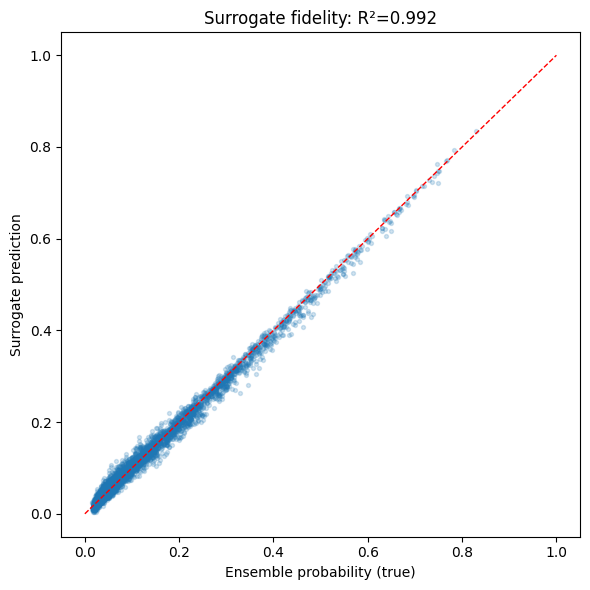

In [8]:
surrogate = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    min_child_weight = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    eval_metric      = 'rmse',
)
surrogate.fit(X_flat, y_target)

# Fidelity check
y_surr = surrogate.predict(X_flat)
r2   = r2_score(y_target, y_surr)
corr = np.corrcoef(y_target, y_surr)[0, 1]
print(f'Surrogate fidelity vs ensemble:')
print(f'  R²         = {r2:.4f}   (>0.85)')
print(f'  Pearson r  = {corr:.4f}')

# Quick scatter: surrogate pred vs true ensemble prob
plt.figure(figsize=(6, 6))
plt.scatter(y_target, y_surr, alpha=0.2, s=8)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)
plt.xlabel('Ensemble probability (true)')
plt.ylabel('Surrogate prediction')
plt.title(f'Surrogate fidelity: R²={r2:.3f}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'surrogate_fidelity_{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. SHAP values (TreeExplainer, fast & exact for trees)

In [9]:
explainer   = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_flat)
print(f'SHAP values shape: {shap_values.shape}')
np.save(OUTPUT_DIR / f'shap_values_{TAG}.npy', shap_values)

SHAP values shape: (4000, 306)


### 6.1 Summary bar (global importance)

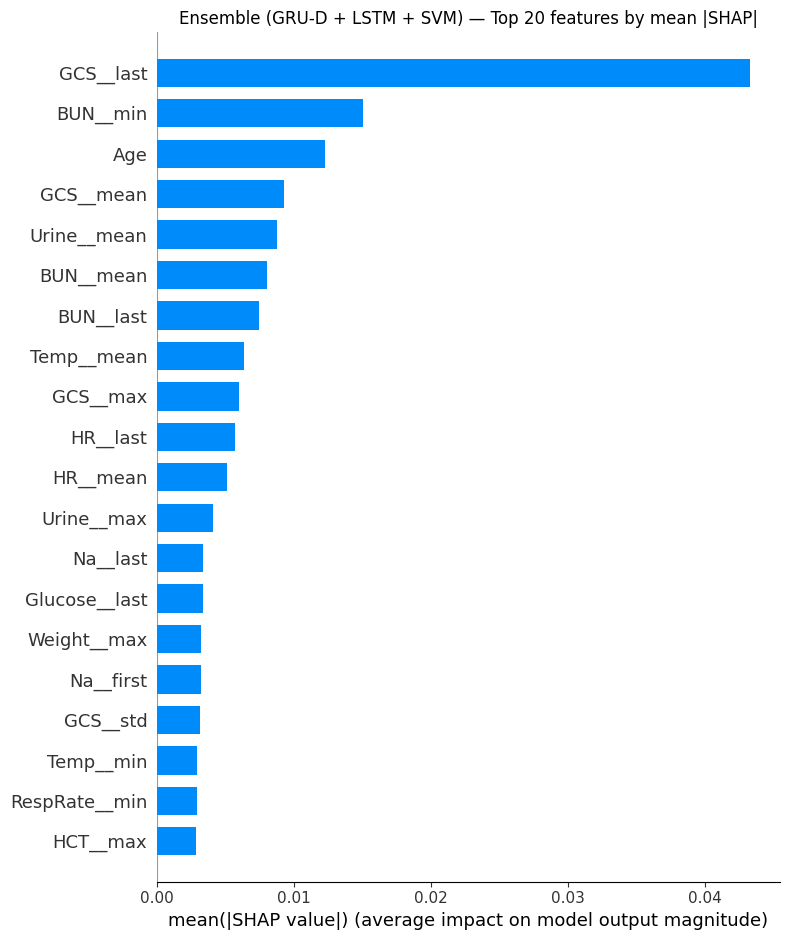

In [10]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_flat,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False,
)
plt.title(f'Ensemble ({LABEL}) — Top 20 features by mean |SHAP|')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'shap_summary_bar_{TAG}.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Beeswarm (feature value × SHAP direction)

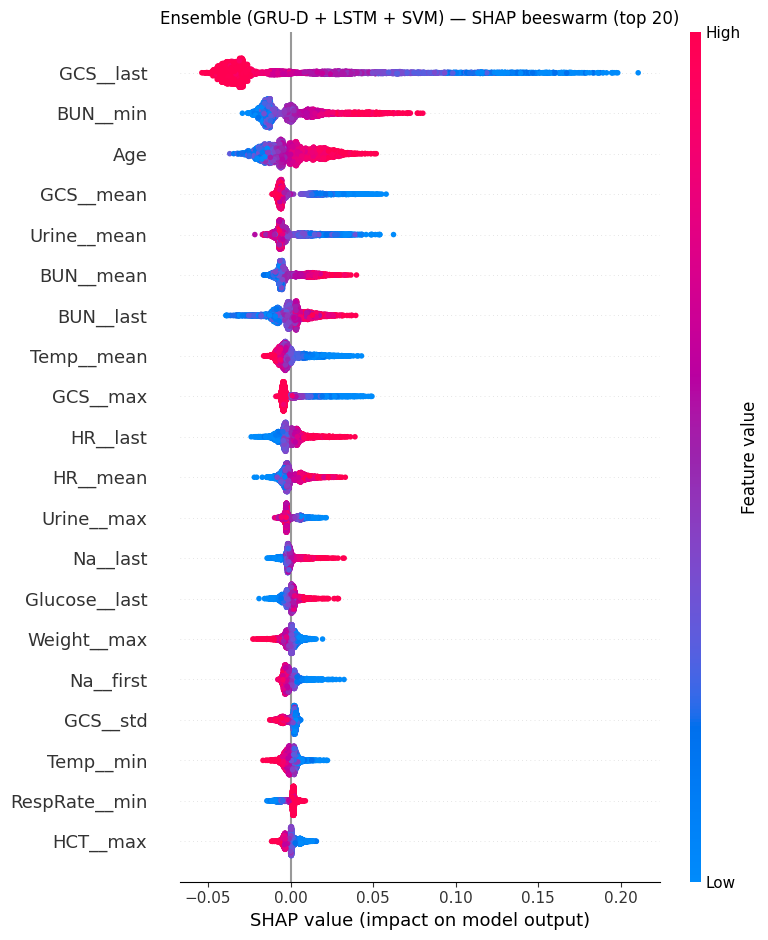

In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_flat,
    feature_names=feature_names,
    plot_type='dot',
    max_display=20,
    show=False,
)
plt.title(f'Ensemble ({LABEL}) — SHAP beeswarm (top 20)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'shap_beeswarm_{TAG}.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Waterfall — highest-risk patient

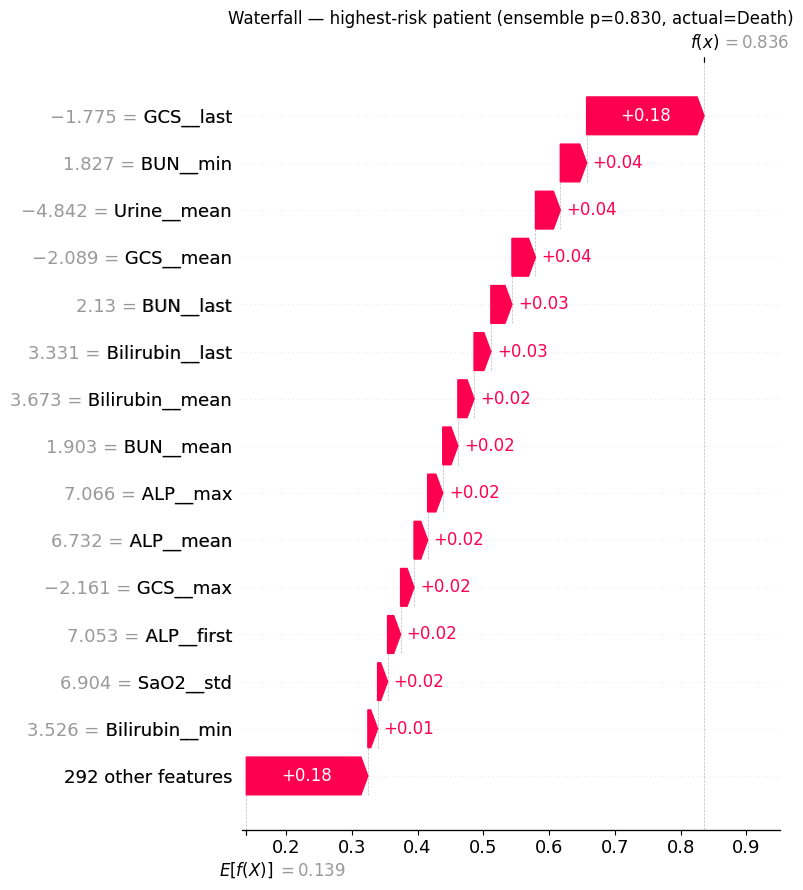

In [12]:
highest_idx = int(np.argmax(y_target))
explanation = shap.Explanation(
    values        = shap_values[highest_idx],
    base_values   = explainer.expected_value,
    data          = X_flat[highest_idx],
    feature_names = feature_names,
)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
actual = 'Death' if y_pool[highest_idx] == 1 else 'Alive'
plt.title(f'Waterfall — highest-risk patient (ensemble p={y_target[highest_idx]:.3f}, actual={actual})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'shap_waterfall_high_{TAG}.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.4 Waterfall — lowest-risk patient (contrast)

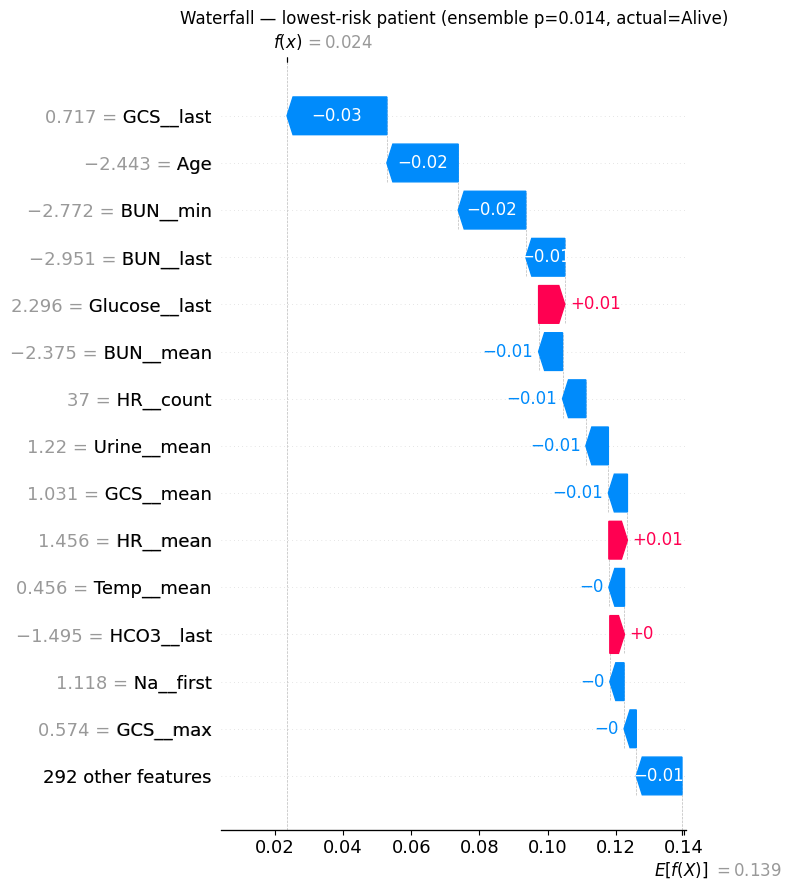

In [13]:
lowest_idx = int(np.argmin(y_target))
explanation_low = shap.Explanation(
    values        = shap_values[lowest_idx],
    base_values   = explainer.expected_value,
    data          = X_flat[lowest_idx],
    feature_names = feature_names,
)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation_low, max_display=15, show=False)
actual = 'Death' if y_pool[lowest_idx] == 1 else 'Alive'
plt.title(f'Waterfall — lowest-risk patient (ensemble p={y_target[lowest_idx]:.3f}, actual={actual})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'shap_waterfall_low_{TAG}.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.5 Feature-importance table (all 306)

In [14]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature':     feature_names,
    'Mean|SHAP|':  mean_abs_shap,
}).sort_values('Mean|SHAP|', ascending=False).reset_index(drop=True)

print('Top 20 features:')
print(importance_df.head(20).to_string(index=False))
importance_df.to_csv(OUTPUT_DIR / f'shap_importance_{TAG}.csv', index=False)
print(f'\nSaved: shap_importance_{TAG}.csv')

Top 20 features:
      Feature  Mean|SHAP|
    GCS__last    0.043343
     BUN__min    0.015034
          Age    0.012285
    GCS__mean    0.009248
  Urine__mean    0.008740
    BUN__mean    0.008021
    BUN__last    0.007436
   Temp__mean    0.006370
     GCS__max    0.005980
     HR__last    0.005686
     HR__mean    0.005127
   Urine__max    0.004091
     Na__last    0.003325
Glucose__last    0.003321
  Weight__max    0.003216
    Na__first    0.003191
     GCS__std    0.003134
    Temp__min    0.002934
RespRate__min    0.002920
     HCT__max    0.002857

Saved: shap_importance_svm.csv


## 7. ICE + PDP plots

ICE = Individual Conditional Expectation: thin lines = how a single patient's predicted probability would change if we varied one feature. PDP (bold) = average of the ICE curves.

In [15]:
# Top SHAP features + clinically meaningful picks
top_shap  = importance_df.head(5)['Feature'].tolist()
clinical  = ['GCS__last', 'BUN__mean', 'HCO3__mean', 'Urine__mean', 'Age']
ICE_FEATURES = list(dict.fromkeys(top_shap + clinical))
print(f'ICE features ({len(ICE_FEATURES)}): {ICE_FEATURES}')

ICE features (7): ['GCS__last', 'BUN__min', 'Age', 'GCS__mean', 'Urine__mean', 'BUN__mean', 'HCO3__mean']


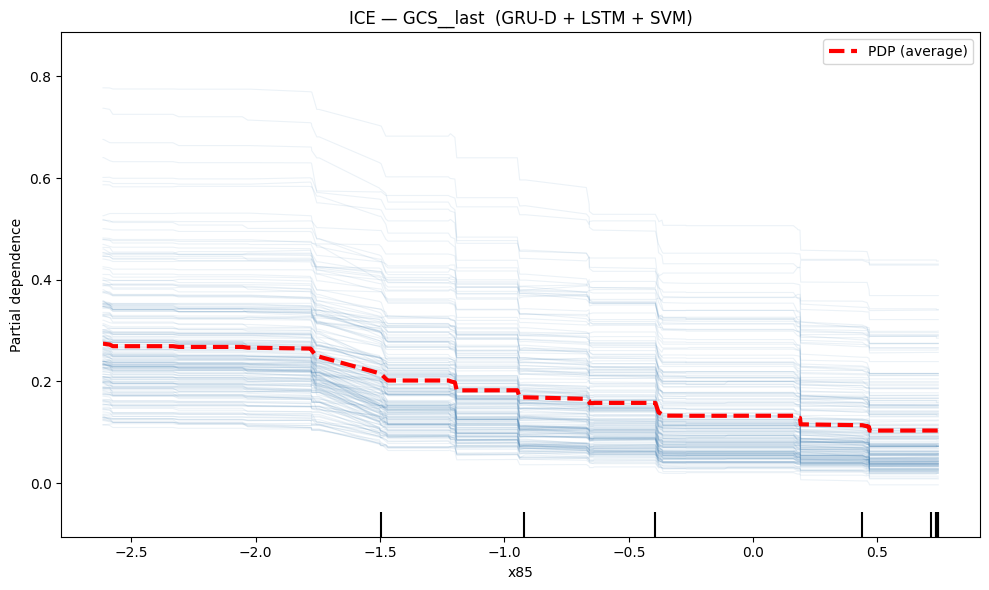

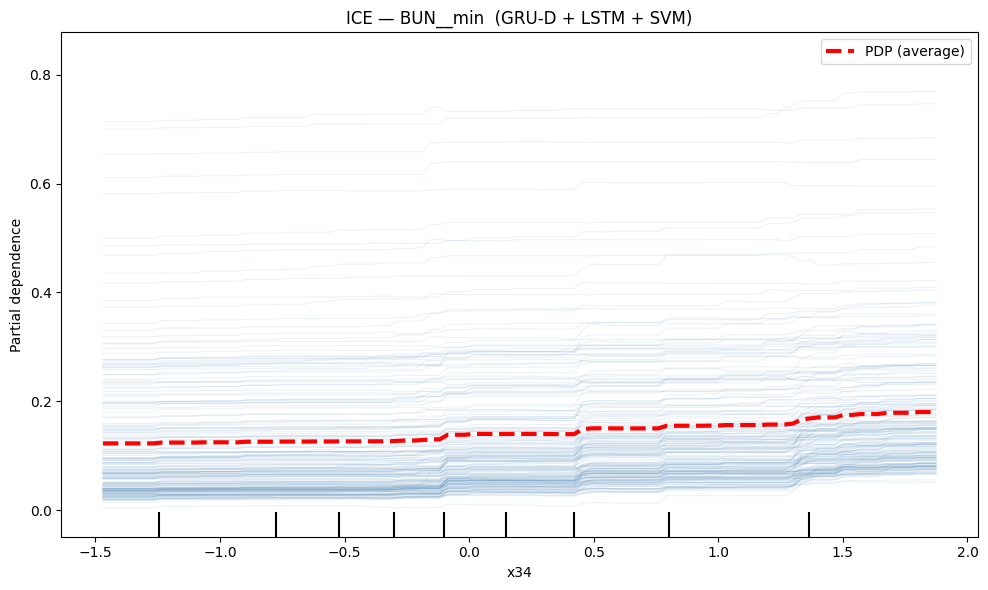

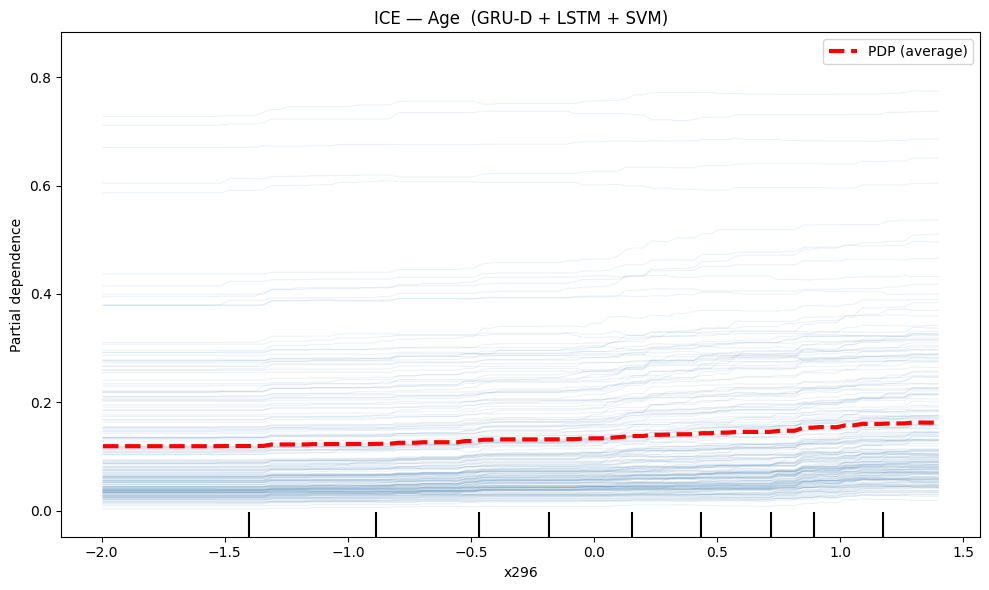

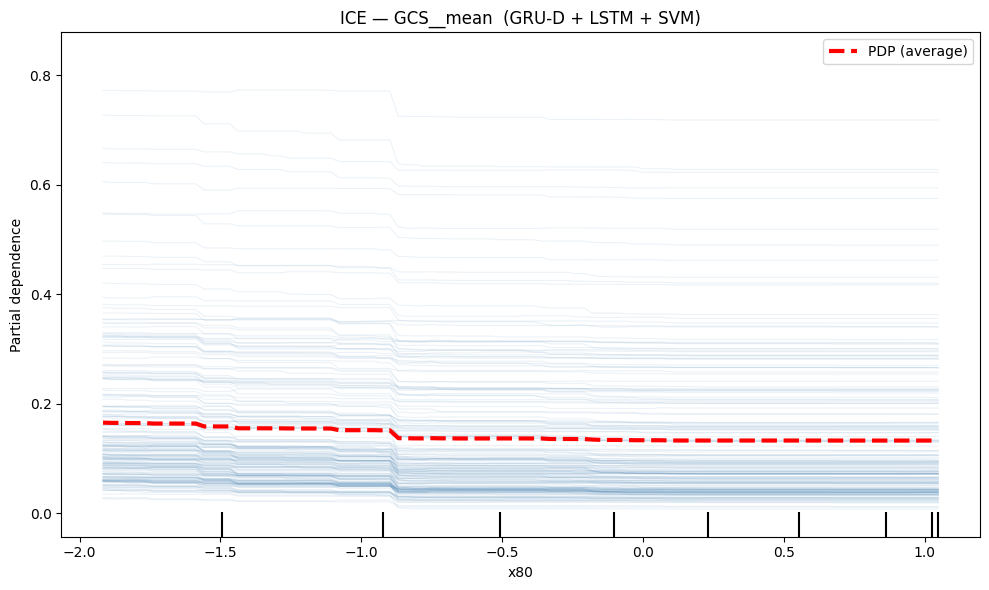

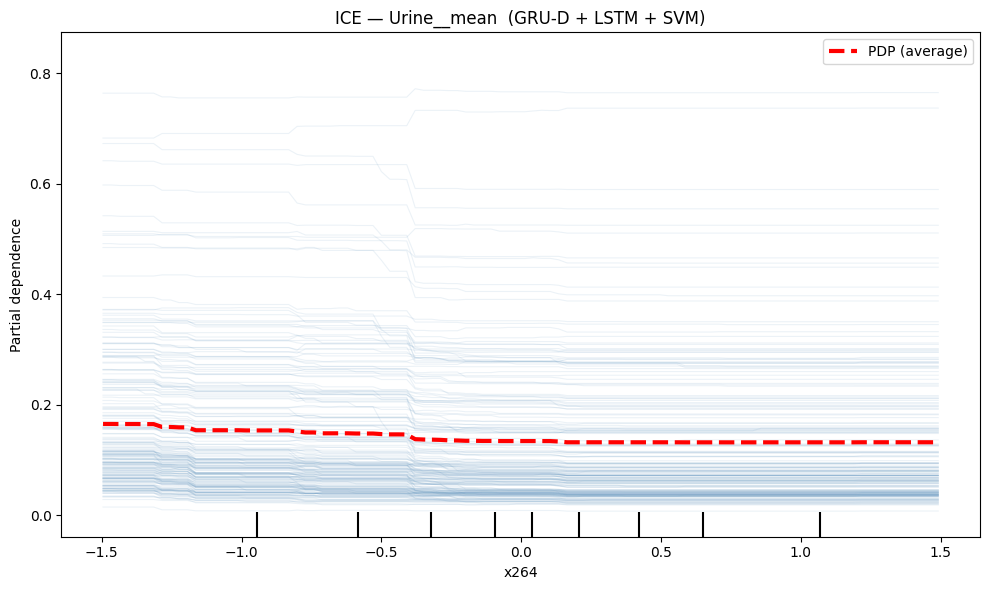

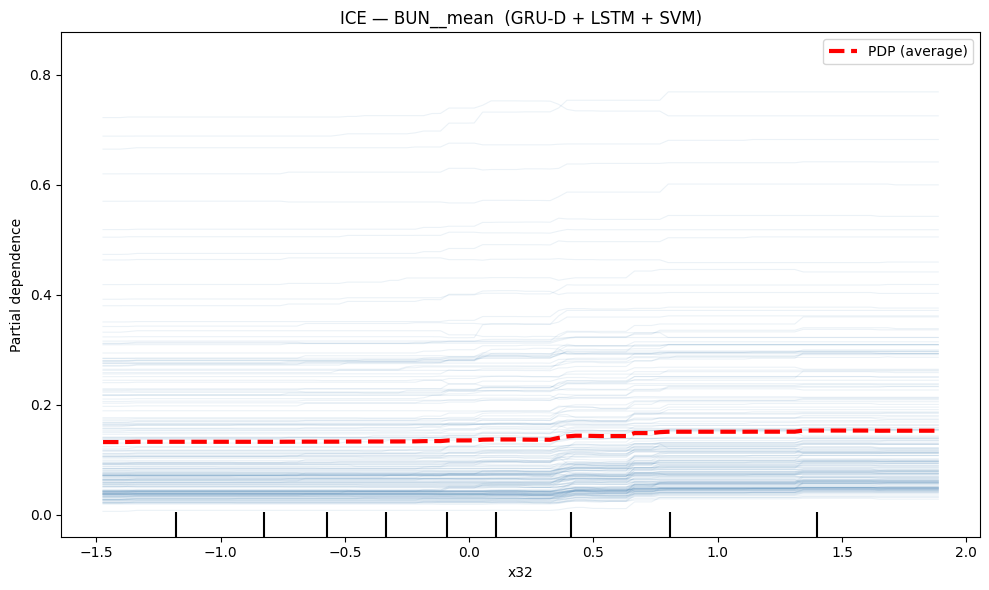

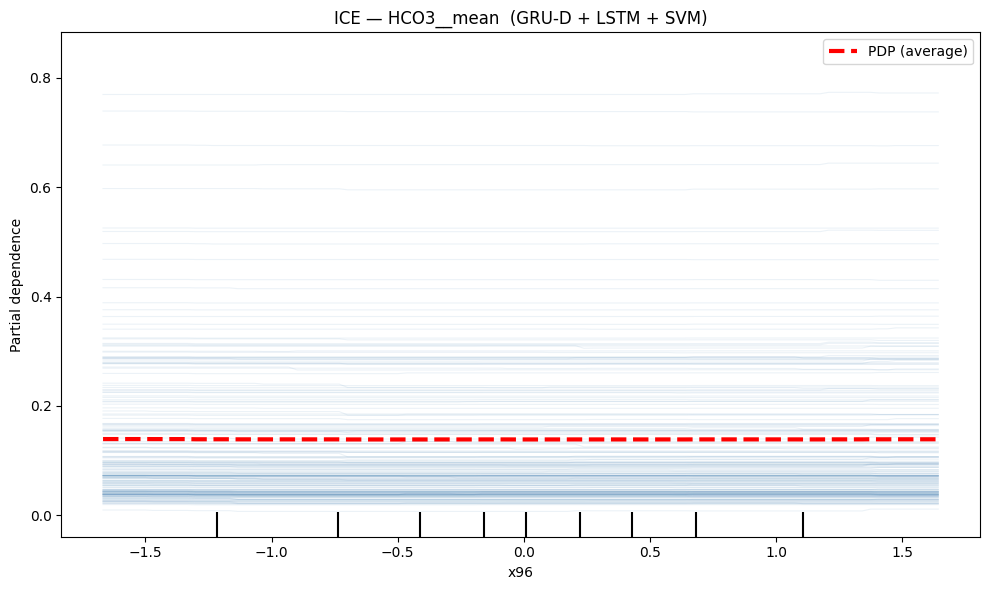

In [16]:
for feat_name in ICE_FEATURES:
    if feat_name not in feature_names:
        print(f'[skip] {feat_name} not in feature list')
        continue
    feat_idx = feature_names.index(feat_name)
    fig, ax = plt.subplots(figsize=(10, 6))
    PartialDependenceDisplay.from_estimator(
        surrogate, X_flat,
        features     = [feat_idx],
        kind         = 'both',
        subsample    = 200,
        n_jobs       = -1,
        random_state = 42,
        ax           = ax,
        pd_line_kw   = {'color': 'red', 'linewidth': 3, 'label': 'PDP (average)'},
        ice_lines_kw = {'color': 'steelblue', 'alpha': 0.1, 'linewidth': 0.8},
    )
    ax.set_title(f'ICE — {feat_name}  ({LABEL})')
    ax.set_xlabel(feat_name)
    ax.set_ylabel('Predicted ensemble probability')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'ice_{feat_name}_{TAG}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Two-way PDP (top-2 SHAP features)

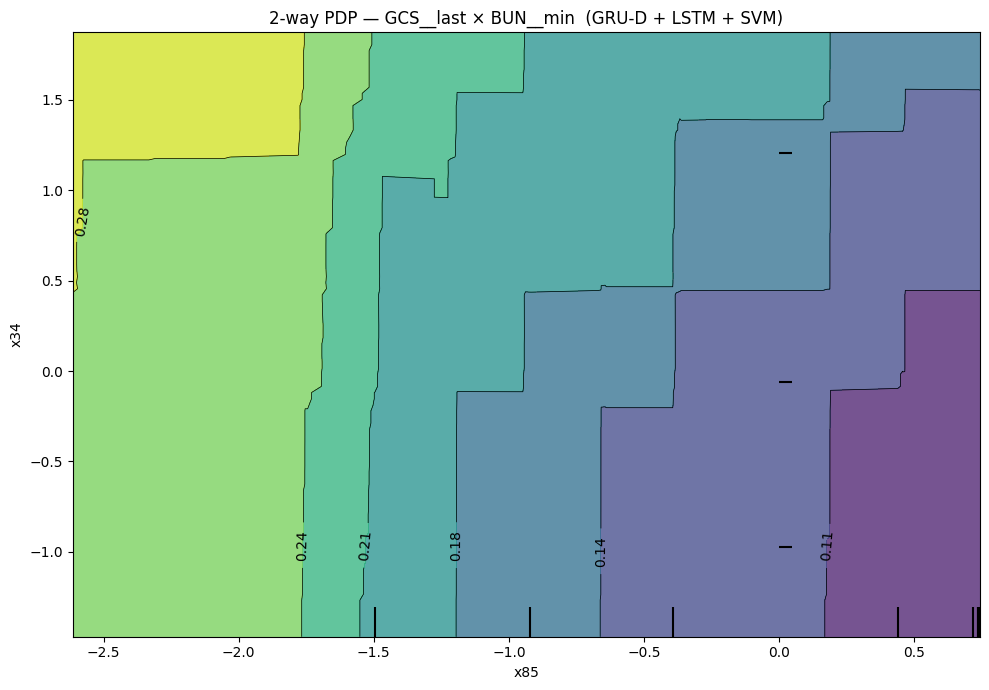

In [17]:
feat1, feat2 = top_shap[0], top_shap[1]
idx1, idx2 = feature_names.index(feat1), feature_names.index(feat2)

fig, ax = plt.subplots(figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    surrogate, X_flat,
    features     = [(idx1, idx2)],
    kind         = 'average',
    n_jobs       = -1,
    random_state = 42,
    ax           = ax,
)
ax.set_title(f'2-way PDP — {feat1} × {feat2}  ({LABEL})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'pdp_2way_{feat1}_{feat2}_{TAG}.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. SHAP dependence plots (single-feature interaction, auto-coloured)

<Figure size 1000x600 with 0 Axes>

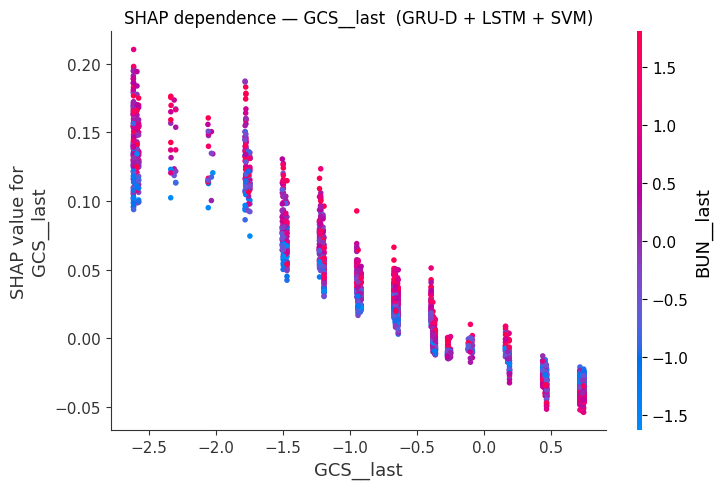

<Figure size 1000x600 with 0 Axes>

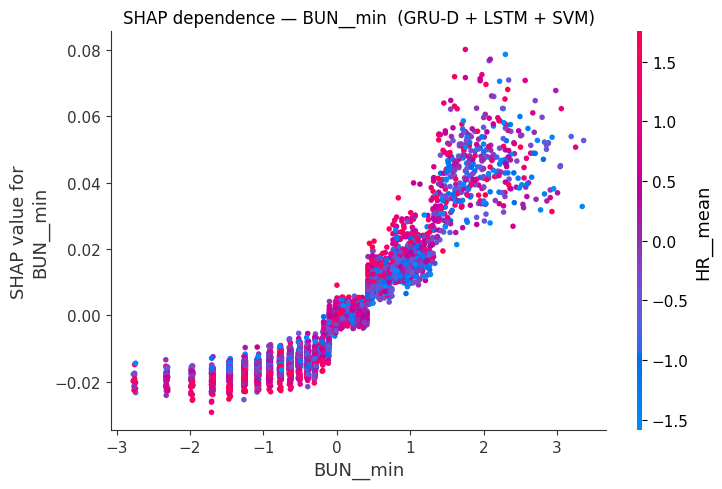

<Figure size 1000x600 with 0 Axes>

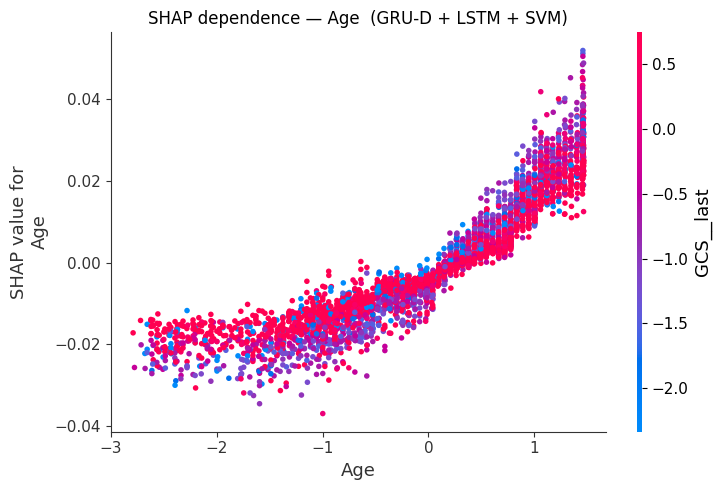

In [18]:
for feat_name in top_shap[:3]:
    feat_idx = feature_names.index(feat_name)
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feat_idx, shap_values, X_flat,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f'SHAP dependence — {feat_name}  ({LABEL})')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'shap_dependence_{feat_name}_{TAG}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. Sanity check: Logistic Regression coefficients

Fit a single LR on the pooled data using the hyperparameters the ensemble actually used. If the top features by |coef| overlap heavily with the top features by |SHAP|, it means the XGBoost surrogate is picking up the same clinical signal that the real ensemble uses — so the surrogate's interpretations are trustworthy.

> **Note**: this LR is a reference fit, not the exact per-fold LR from `lr_results`. It's used only as a directional consistency check.

In [19]:
lr_cfg = lr_results['config']
print(f'LR config used in ensemble: {lr_cfg}')

lr_sanity = LogisticRegression(
    C           = lr_cfg.get('C', 1.0),
    penalty     = lr_cfg.get('penalty', 'l2'),
    solver      = lr_cfg.get('solver', 'lbfgs'),
    max_iter    = 5000,
    random_state= 42,
)
lr_sanity.fit(X_flat, y_pool)
coef = lr_sanity.coef_.ravel()

coef_df = pd.DataFrame({
    'Feature':  feature_names,
    'LR_coef':  coef,
    'Abs_coef': np.abs(coef),
}).sort_values('Abs_coef', ascending=False).reset_index(drop=True)

print('\nTop 15 LR features (|coef|):')
print(coef_df.head(15).to_string(index=False))

shap_top = set(importance_df.head(15)['Feature'])
lr_top   = set(coef_df.head(15)['Feature'])
overlap  = shap_top & lr_top
print(f'\nOverlap in top 15 (SHAP vs LR): {len(overlap)}/15  ({len(overlap)/15:.0%})')
print(f'Common features: {sorted(overlap)}')

coef_df.to_csv(OUTPUT_DIR / f'lr_sanity_coefs_{TAG}.csv', index=False)

LR config used in ensemble: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000}

Top 15 LR features (|coef|):
         Feature   LR_coef  Abs_coef
       GCS__last -0.447219  0.447219
             Age  0.279622  0.279622
       GCS__mean -0.197129  0.197129
     Urine__mean -0.164345  0.164345
       BUN__last  0.151714  0.151714
        GCS__max -0.146601  0.146601
        pH__mean  0.140787  0.140787
   Glucose__last  0.125111  0.125111
         pH__std  0.117638  0.117638
       Temp__min -0.112725  0.112725
     HCO3__count -0.110409  0.110409
        HR__last  0.108664  0.108664
       ICUType_2 -0.108074  0.108074
         pH__min -0.107432  0.107432
TroponinI__count  0.103380  0.103380

Overlap in top 15 (SHAP vs LR): 8/15  (53%)
Common features: ['Age', 'BUN__last', 'GCS__last', 'GCS__max', 'GCS__mean', 'Glucose__last', 'HR__last', 'Urine__mean']


## 11. Output summary

In [20]:
print(f'=== Files in {OUTPUT_DIR} ===')
for f in sorted(OUTPUT_DIR.iterdir()):
    kb = f.stat().st_size / 1024
    print(f'  {f.name:55s}  {kb:8.1f} KB')

=== Files in D:\Coding\py\py_Project\DATA5925\artifacts\results\dual_ensemble_notebooks\shap_ice_analysis ===
  ensemble_lr                                                   8.0 KB
  ensemble_svm                                                  0.0 KB
  ice_Age_svm.png                                             412.8 KB
  ice_BUN__mean_svm.png                                       260.4 KB
  ice_BUN__min_svm.png                                        387.3 KB
  ice_GCS__last_svm.png                                       584.1 KB
  ice_GCS__mean_svm.png                                       320.4 KB
  ice_HCO3__mean_svm.png                                      122.7 KB
  ice_Urine__mean_svm.png                                     321.9 KB
  lr_sanity_coefs_svm.csv                                      16.6 KB
  pdp_2way_GCS__last_BUN__min_svm.png                         133.0 KB
  shap_beeswarm_svm.png                                       456.0 KB
  shap_dependence_Age_svm.png         